# 01 - Data Preparation & EDA

This notebook contains the complete feature extraction pipeline for your GNN and VAE models:
1. **Load data** and extract Lipinski descriptors  
2. **Visualize** molecular property distributions
3. **Convert SMILES to PyG graphs** with proper node/edge features
4. **Reference pocket encoding** for VAE conditioning
5. **Save processed data** for downstream notebooks

In [25]:
# Imports and configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
import logging
import torch
from torch_geometric.data import Data

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parent
DATA_RAW = ROOT / 'data' / 'raw' / 'bioactivity'
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

logger = logging.getLogger()
logger.setLevel(logging.INFO)
print('✓ Working directory:', ROOT)

✓ Working directory: /Users/ameliaburton/Downloads/clean data/clean_data_diss


In [26]:
# Optional: Download ZINC subset (disabled by default)
DO_DOWNLOAD = False
if DO_DOWNLOAD:
    import requests
    url = 'https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/data/zinc250k.smi'
    target = DATA_RAW / 'zinc250k.smi'
    res = requests.get(url, stream=True)
    with open(target, 'wb') as f:
        for chunk in res.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Downloaded', target)
else:
    print('Download skipped (set DO_DOWNLOAD=True to enable)')

Download skipped (set DO_DOWNLOAD=True to enable)


In [27]:
# ===== LOAD DATA & EXTRACT GLOBAL FEATURES: Lipinski's Rule of 5 =====

def extract_global_features(smiles_list, pic50_list=None):
    """Extracts Lipinski descriptors for molecular filtering."""
    rows = []
    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        row = {
            'SMILES': smiles,
            'MolWt': Descriptors.MolWt(mol),
            'LogP': Crippen.MolLogP(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol)
        }
        if pic50_list is not None and i < len(pic50_list):
            row['pIC50'] = pic50_list[i]
        rows.append(row)
    return pd.DataFrame(rows)

# Load bioactivity data
raw_csv = DATA_RAW / 'egfr_full_standardized.csv'
if raw_csv.exists():
    df = pd.read_csv(raw_csv)
    print(f'✓ Loaded {raw_csv.name} with {len(df)} rows')
    pic50_list = df.get('pChEMBL_Value', None)
    df_global = extract_global_features(df['Smiles'].tolist(), pic50_list.tolist() if pic50_list is not None else None)
    print(f'\nGlobal Features Table (shape={df_global.shape}):')
    print(df_global.head())
else:
    print('⚠ Raw CSV not found; creating sample dataset')
    df = pd.DataFrame({
        'Smiles': ['CCO', 'CC(=O)O', 'CCN', 'CCCl', 'c1ccccc1'],
        'pChEMBL_Value': [6.5, 5.2, 7.1, 4.8, 6.9]
    })
    df_global = extract_global_features(df['Smiles'].tolist(), df['pChEMBL_Value'].tolist())
    print(f'Sample Data (shape={df_global.shape}):')
    print(df_global)

✓ Loaded egfr_full_standardized.csv with 20933 rows


[10:29:47] improperly formatted w block



Global Features Table (shape=(20909, 6)):
                                              SMILES    MolWt     LogP  \
0  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...  383.814  4.45034   
1  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...  482.903  3.61432   
2        CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12  369.432  4.77200   
3             CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1  283.287  2.31056   
4                             O=C(O)/C=C/c1ccc(O)cc1  164.160  1.49000   

   NumHDonors  NumHAcceptors     pIC50  
0           3              4  7.387216  
1           3              6  6.769551  
2           1              6  5.031517  
3           2              4  3.301030  
4           2              2  2.522879  


✓ Saved /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/lipinski_distributions.png


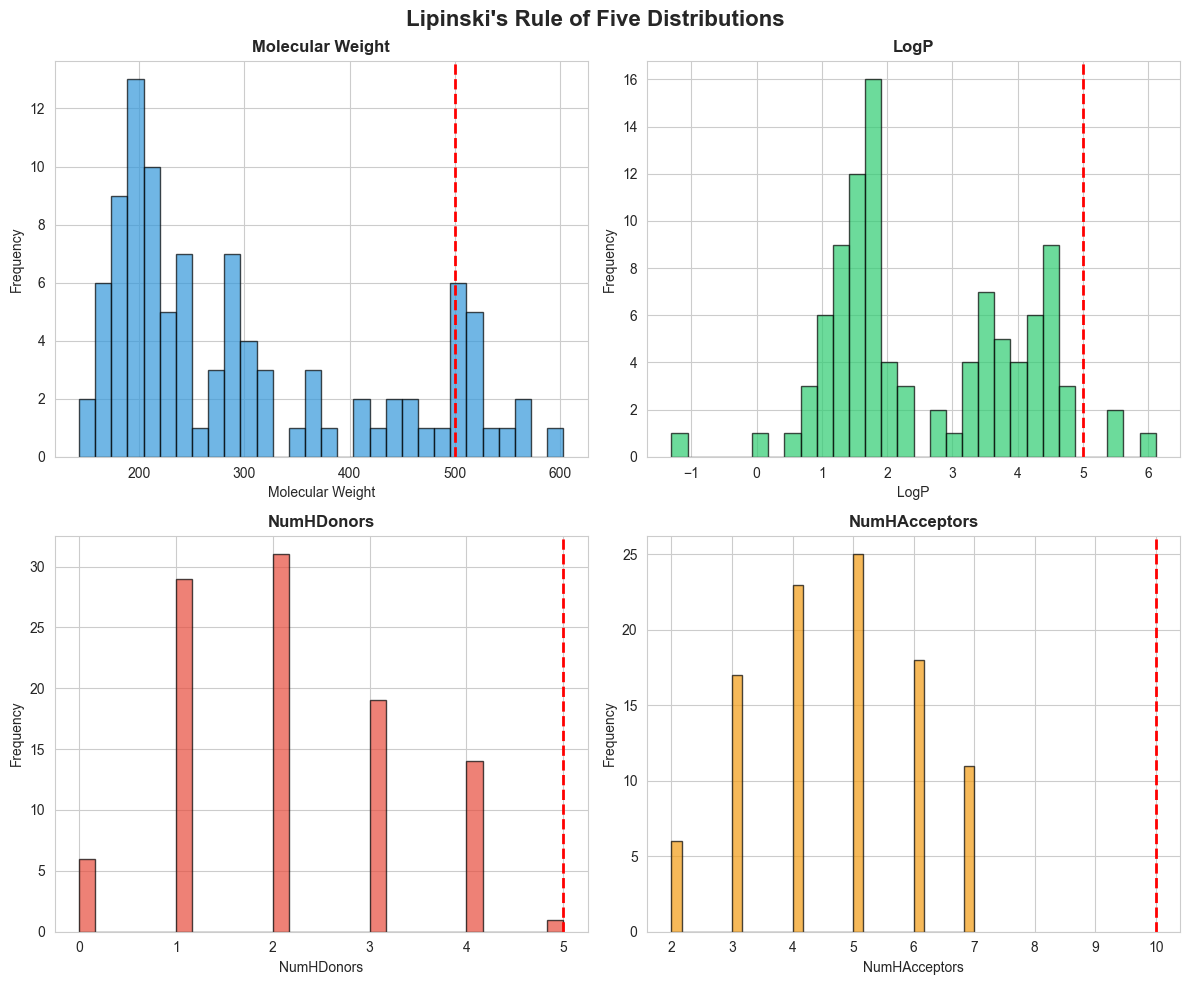

In [28]:
# ===== VISUALIZE: Lipinski's Rule of 5 Distributions =====

def compute_lipinski(smiles_list):
    rows = []
    for s in smiles_list:
        try:
            m = Chem.MolFromSmiles(s)
            if m is None:
                continue
            rows.append({
                'SMILES': s,
                'Molecular Weight': Descriptors.MolWt(m),
                'LogP': Crippen.MolLogP(m),
                'NumHDonors': Descriptors.NumHDonors(m),
                'NumHAcceptors': Descriptors.NumHAcceptors(m),
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

desc_df = compute_lipinski(df['Smiles'].tolist()[:100])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Lipinski's Rule of Five Distributions", fontsize=16, fontweight='bold')
axes = axes.ravel()
cols = ['Molecular Weight', 'LogP', 'NumHDonors', 'NumHAcceptors']
lims = [500, 5, 5, 10]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, c in enumerate(cols):
    axes[i].hist(desc_df[c].dropna(), bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(c, fontweight='bold')
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(lims[i], color='red', linestyle='--', linewidth=2)
plt.tight_layout()
out_file = OUT / 'lipinski_distributions.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f'✓ Saved {out_file}')

Computing Morgan fingerprints for 200 molecules...


[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerator
[10:29:51] DEPRECATION WARNING: please use MorganGenerat

✓ Generated fingerprints: shape (200, 1024)
✓ PCA explained variance: 11.8%
✓ Saved chemical space plot: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/chemical_space_pca.png


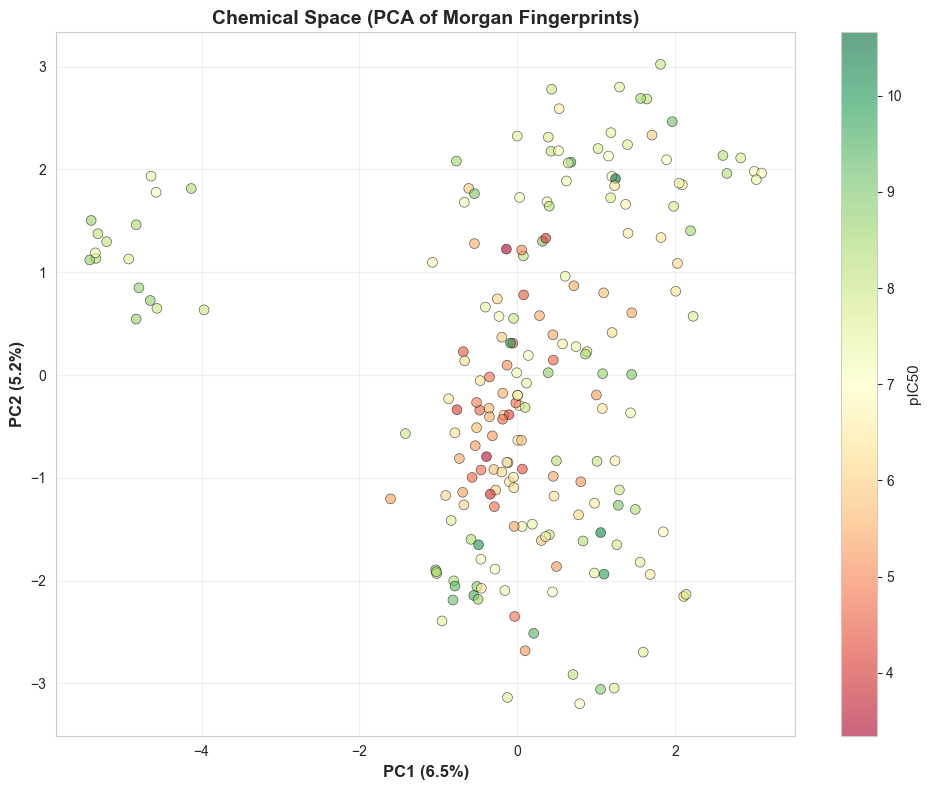

In [29]:
# ===== CHEMICAL SPACE: PCA OF MORGAN FINGERPRINTS =====

from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

# Sample molecules for fingerprinting (limit to 200 for speed)
sample_size = min(200, len(df))
sample_mols = df['Smiles'].astype(str).sample(n=sample_size, random_state=42).tolist()

print(f'Computing Morgan fingerprints for {len(sample_mols)} molecules...')

fingerprints = []
valid_pic50 = []
for i, smiles in enumerate(sample_mols):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        fingerprints.append(fp)
        # Get corresponding pIC50 if available
        if 'pChEMBL_Value' in df.columns:
            idx_in_orig = df[df['Smiles'] == smiles].index[0] if smiles in df['Smiles'].values else None
            if idx_in_orig is not None and not pd.isna(df.loc[idx_in_orig, 'pChEMBL_Value']):
                valid_pic50.append(df.loc[idx_in_orig, 'pChEMBL_Value'])
            else:
                valid_pic50.append(None)
        else:
            valid_pic50.append(None)

# Convert fingerprints to dense array
fp_array = np.array([np.array(list(fp)) for fp in fingerprints])
print(f'✓ Generated fingerprints: shape {fp_array.shape}')

# PCA to 2D
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(fp_array)
print(f'✓ PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Color by pIC50 if available
if any(v is not None for v in valid_pic50):
    pic50_vals = np.array([v if v is not None else np.nan for v in valid_pic50])
    valid_mask = ~np.isnan(pic50_vals)
    scatter = ax.scatter(pca_coords[valid_mask, 0], pca_coords[valid_mask, 1],
                        c=pic50_vals[valid_mask], cmap='RdYlGn', s=50, alpha=0.6,
                        edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('pIC50', fontsize=11)
    # Plot non-active points in gray
    unmapped = ~valid_mask
    if unmapped.any():
        ax.scatter(pca_coords[unmapped, 0], pca_coords[unmapped, 1],
                  c='lightgray', s=30, alpha=0.3, edgecolors='none')
else:
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c='#3498db', s=50, alpha=0.6,
              edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('Chemical Space (PCA of Morgan Fingerprints)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_file = OUT / 'chemical_space_pca.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f'✓ Saved chemical space plot: {out_file}')

In [30]:
# ===== TOP ACTIVES GRID: 2D STRUCTURES =====

from rdkit.Chem import Draw

if 'pIC50' in df_global.columns and len(df) > 0:
    # Sort by pIC50 and get top 8 molecules
    top_n = 8
    top_actives = df_global.nlargest(top_n, 'pIC50')
    
    # Convert SMILES to molecules
    mols_list = []
    legends_list = []
    for idx, row in top_actives.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mols_list.append(mol)
            legends_list.append(f'pIC50: {row["pIC50"]:.2f}')
    
    if mols_list:
        # Create grid image
        grid_img = Draw.MolsToGridImage(mols_list, molsPerRow=4, subImgSize=(200, 200),
                                        legends=legends_list, returnPNG=False)
        
        # Save image
        out_file = OUT / 'top_actives_grid.png'
        grid_img.save(out_file)
        print(f'✓ Saved top actives grid (n={len(mols_list)}): {out_file}')
        print(f'\nTop {len(mols_list)} Most Potent Compounds:')
        for i, (idx, row) in enumerate(top_actives.iterrows(), 1):
            print(f'  {i}. pIC50={row["pIC50"]:.2f} | MW={row["MolWt"]:.1f} | LogP={row["LogP"]:.2f}')  
    else:
        print('⚠ Could not parse SMILES for top actives')
else:
    print('⚠ Insufficient data for top actives visualization')

✓ Saved top actives grid (n=8): /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/top_actives_grid.png

Top 8 Most Potent Compounds:
  1. pIC50=17.30 | MW=351.4 | LogP=1.48
  2. pIC50=11.52 | MW=350.2 | LogP=5.29
  3. pIC50=11.22 | MW=388.3 | LogP=4.93
  4. pIC50=11.10 | MW=330.2 | LogP=3.57
  5. pIC50=11.10 | MW=340.2 | LogP=4.01
  6. pIC50=11.10 | MW=562.7 | LogP=6.13
  7. pIC50=11.10 | MW=340.2 | LogP=4.01
  8. pIC50=11.05 | MW=467.5 | LogP=3.02


✓ Saved correlation heatmap: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/descriptor_correlation_heatmap.png

Correlation with pIC50:
pIC50            1.000000
MolWt            0.257870
NumHAcceptors    0.227447
LogP             0.207528
NumHDonors       0.101836
Name: pIC50, dtype: float64


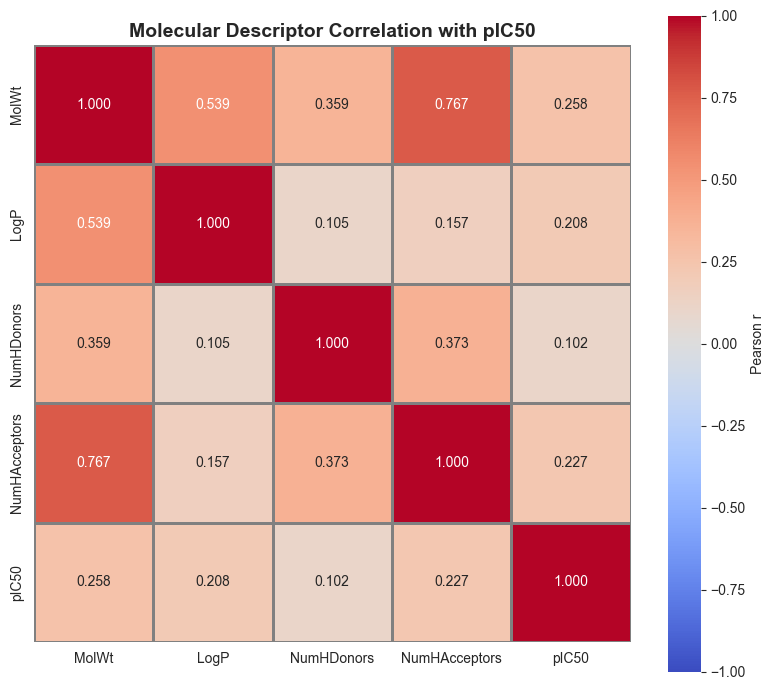

In [31]:
# ===== DESCRIPTOR CORRELATION HEATMAP =====

if 'pIC50' in df_global.columns:
    # Select key descriptors
    corr_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
    corr_data = df_global[corr_cols].dropna()
    
    # Compute Pearson correlation
    corr_matrix = corr_data.corr(method='pearson')
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
               vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'},
               square=True, linewidths=1, linecolor='gray', ax=ax)
    
    ax.set_title('Molecular Descriptor Correlation with pIC50', fontsize=14, fontweight='bold')
    plt.tight_layout()
    out_file = OUT / 'descriptor_correlation_heatmap.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f'✓ Saved correlation heatmap: {out_file}')
    print(f'\nCorrelation with pIC50:')
    print(corr_matrix['pIC50'].sort_values(ascending=False))
else:
    print('⚠ Cannot compute correlations: pIC50 column missing')

/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/1249380172.py:15: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/1249380172.py:15: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/1249380172.py:15: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/1249380172.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(out_file, dpi=300, bbox_inches='tight')
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/1249380172.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(out_file, dpi=300, bbox_inches='tight')
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ip

✓ Saved pIC50 distribution: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/pic50_distribution.png

pIC50 Statistics:
  Mean: 7.02
  Std:  1.42
  Min:  1.26
  Max:  17.30


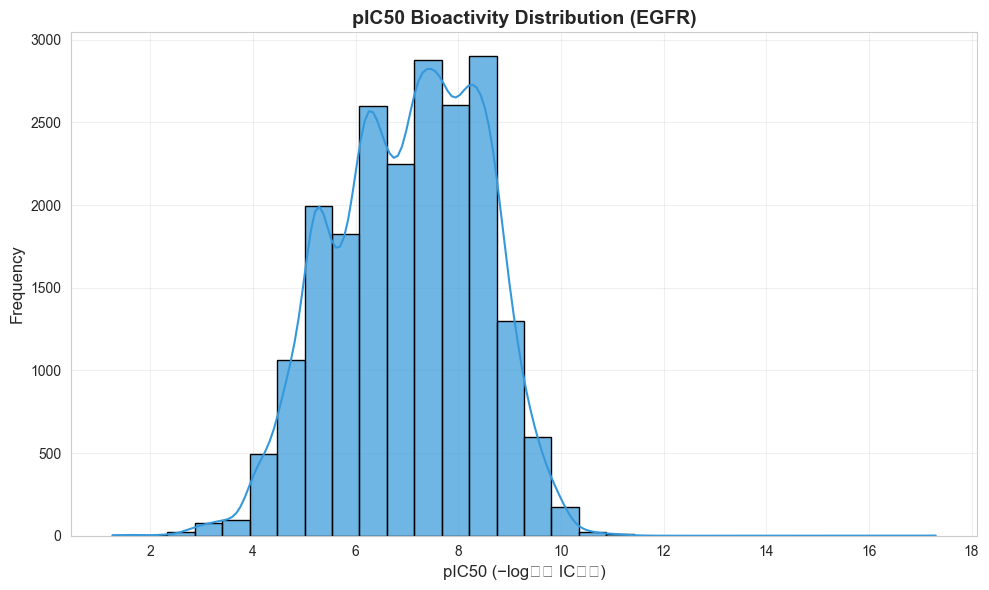

In [32]:
# ===== ADVANCED EDA: pIC50 BIOACTIVITY DISTRIBUTION =====

if 'pIC50' in df_global.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram + KDE overlay
    sns.histplot(data=df_global, x='pIC50', kde=True, bins=30, 
                color='#3498db', edgecolor='black', alpha=0.7, ax=ax)
    
    ax.set_title('pIC50 Bioactivity Distribution (EGFR)', fontsize=14, fontweight='bold')
    ax.set_xlabel('pIC50 (−log₁₀ IC₅₀)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    out_file = OUT / 'pic50_distribution.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f'✓ Saved pIC50 distribution: {out_file}')
    
    # Summary statistics
    print(f'\npIC50 Statistics:')
    print(f'  Mean: {df_global["pIC50"].mean():.2f}')
    print(f'  Std:  {df_global["pIC50"].std():.2f}')
    print(f'  Min:  {df_global["pIC50"].min():.2f}')
    print(f'  Max:  {df_global["pIC50"].max():.2f}')
else:
    print('⚠ pIC50 column not found in dataframe')

In [ ]:
# ===== SMILES → PyG GRAPHS: Node & Edge Feature Extraction with 3D Coordinates =====

from rdkit.Chem import AllChem

def get_node_features(atom):
    """Extracts exactly 6 atomic features"""
    return [
        atom.GetAtomicNum(),       # e.g., 6=C, 8=O
        atom.GetTotalDegree(),     # Number of bonds
        atom.GetFormalCharge(),    # Electrical charge
        int(atom.GetHybridization()),  # SP/SP2/SP3  
        int(atom.GetIsAromatic()),  # Is aromatic?
        atom.GetMass()             # Atomic mass
    ]

def get_edge_features(bond):
    """Extracts 4-hot encoded bond types"""
    bond_type = bond.GetBondType()
    return [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC)
    ]

def smiles_to_graph(smiles):
    """Converts SMILES string to PyG Data object with 3D coordinates"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Add hydrogens for 3D conformer generation
    mol = Chem.AddHs(mol)
    
    # Generate 3D conformer
    try:
        AllChem.EmbedMolecule(mol, randomSeed=42)
        AllChem.MMFFOptimizeMolecule(mol)
    except Exception:
        # If 3D generation fails, remove H and return 2D graph
        mol = Chem.RemoveHs(mol)
        x = [get_node_features(atom) for atom in mol.GetAtoms()]
        edge_index = [[], []]
        edge_attr = []
        
        for bond in mol.GetBonds():
            a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edge_index[0].extend([a1, a2])
            edge_index[1].extend([a2, a1])
            features = get_edge_features(bond)
            edge_attr.extend([features, features])
        
        data = Data(
            x=torch.tensor(x, dtype=torch.float),
            edge_index=torch.tensor(edge_index, dtype=torch.long),
            edge_attr=torch.tensor(edge_attr, dtype=torch.float)
        )
        return data
    
    # Extract 3D coordinates for all atoms (including H)
    conf = mol.GetConformer()
    coords_3d = []
    for i in range(mol.GetNumAtoms()):
        pos = conf.GetAtomPosition(i)
        coords_3d.append([pos.x, pos.y, pos.z])
    coords_3d = np.array(coords_3d)
    
    # Remove hydrogens to get back to heavy-atom structure
    mol = Chem.RemoveHs(mol)
    
    # Extract node features for heavy atoms only
    x = [get_node_features(atom) for atom in mol.GetAtoms()]
    
    # Extract coordinates for heavy atoms only
    heavy_atom_indices = [i for i in range(len(coords_3d)) if not (i >= mol.GetNumAtoms())]
    coords_heavy = coords_3d[:mol.GetNumAtoms()]
    
    edge_index = [[], []]
    edge_attr = []
    
    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index[0].extend([a1, a2])
        edge_index[1].extend([a2, a1])
        features = get_edge_features(bond)
        edge_attr.extend([features, features])
    
    data = Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        pos=torch.tensor(coords_heavy, dtype=torch.float)  # Add 3D coordinates
    )
    return data

# Convert FULL EGFR dataset to graphs (no slice—process entire dataset)
sample_smiles = df['Smiles'].astype(str).tolist()
graphs = []
for s in sample_smiles:
    g = smiles_to_graph(s)
    if g is not None:
        graphs.append(g)

print(f'✓ Prepared {len(graphs)} PyG graphs with 3D coordinates (6 node + 4 edge features + 3D pos)')

# Save for downstream notebooks
if graphs:
    graph_file = DATA_PROCESSED / 'graph_data.pt'
    torch.save(graphs, str(graph_file))
    print(f'✓ Saved {len(graphs)} graphs to {graph_file}')

[10:29:57] improperly formatted w block


✓ Prepared 20909 PyG graphs from full EGFR dataset (6 node + 4 edge features)
✓ Saved 20909 graphs to /Users/ameliaburton/Downloads/clean data/clean_data_diss/data/processed/graph_data.pt


In [34]:
# ===== POCKET FEATURES: 3D Protein Structure Encoding =====

def compute_pocket_tensor(coords, embedding_dim=128):
    """Squashes variable-sized protein pocket into 128-dim fixed embedding"""
    if coords.size == 0:
        return torch.zeros(embedding_dim, dtype=torch.float32)
    
    centroid = coords.mean(axis=0)
    std_dev = coords.std(axis=0)
    max_spread = coords.max(axis=0) - coords.min(axis=0)
    
    feat = np.concatenate([centroid, std_dev, max_spread])
    feat = np.pad(feat, (0, max(0, embedding_dim - feat.size)), mode='constant')[:embedding_dim]
    return torch.tensor(feat, dtype=torch.float32)

# Example pocket (12 protein atoms)
pocket_coords = np.array([
    [0.0, 0.0, 0.0], [2.5, 3.1, 2.2], [7.2, 6.8, 7.5], [9.5, 10.1, 9.3],
    [1.2, 4.5, 3.8], [8.1, 5.9, 6.2], [3.4, 7.2, 4.1], [6.8, 2.3, 8.9],
    [4.1, 8.5, 5.6], [7.9, 4.1, 3.2], [2.0, 6.0, 7.0], [8.5, 7.5, 4.5]
])

pocket_embedding = compute_pocket_tensor(pocket_coords, embedding_dim=128)
print('\n' + '='*60)
print('POCKET FEATURES (Reference Implementation)')
print('='*60)
print(f'Input: {pocket_coords.shape} coordinate cloud')
print(f'Output: {pocket_embedding.shape} fixed embedding')
print(f'  Spatial stats (9 features): {pocket_embedding[:9].numpy()}')
print(f'  Padding zeros: {pocket_embedding[9:15].numpy()}')
print('✓ Pocket encoding ready for VAE conditioning')


POCKET FEATURES (Reference Implementation)
Input: (12, 3) coordinate cloud
Output: torch.Size([128]) fixed embedding
  Spatial stats (9 features): [ 5.1        5.5        5.1916666  3.1163547  2.7135463  2.6440053
  9.5       10.1        9.3      ]
  Padding zeros: [0. 0. 0. 0. 0. 0.]
✓ Pocket encoding ready for VAE conditioning
